Time column is increasing: True
Missing values:
0_x      0
13_x     0
14_x     0
17_x     0
37_x     0
        ..
375_y    0
402_y    0
405_y    0
409_y    0
415_y    0
Length: 80, dtype: int64


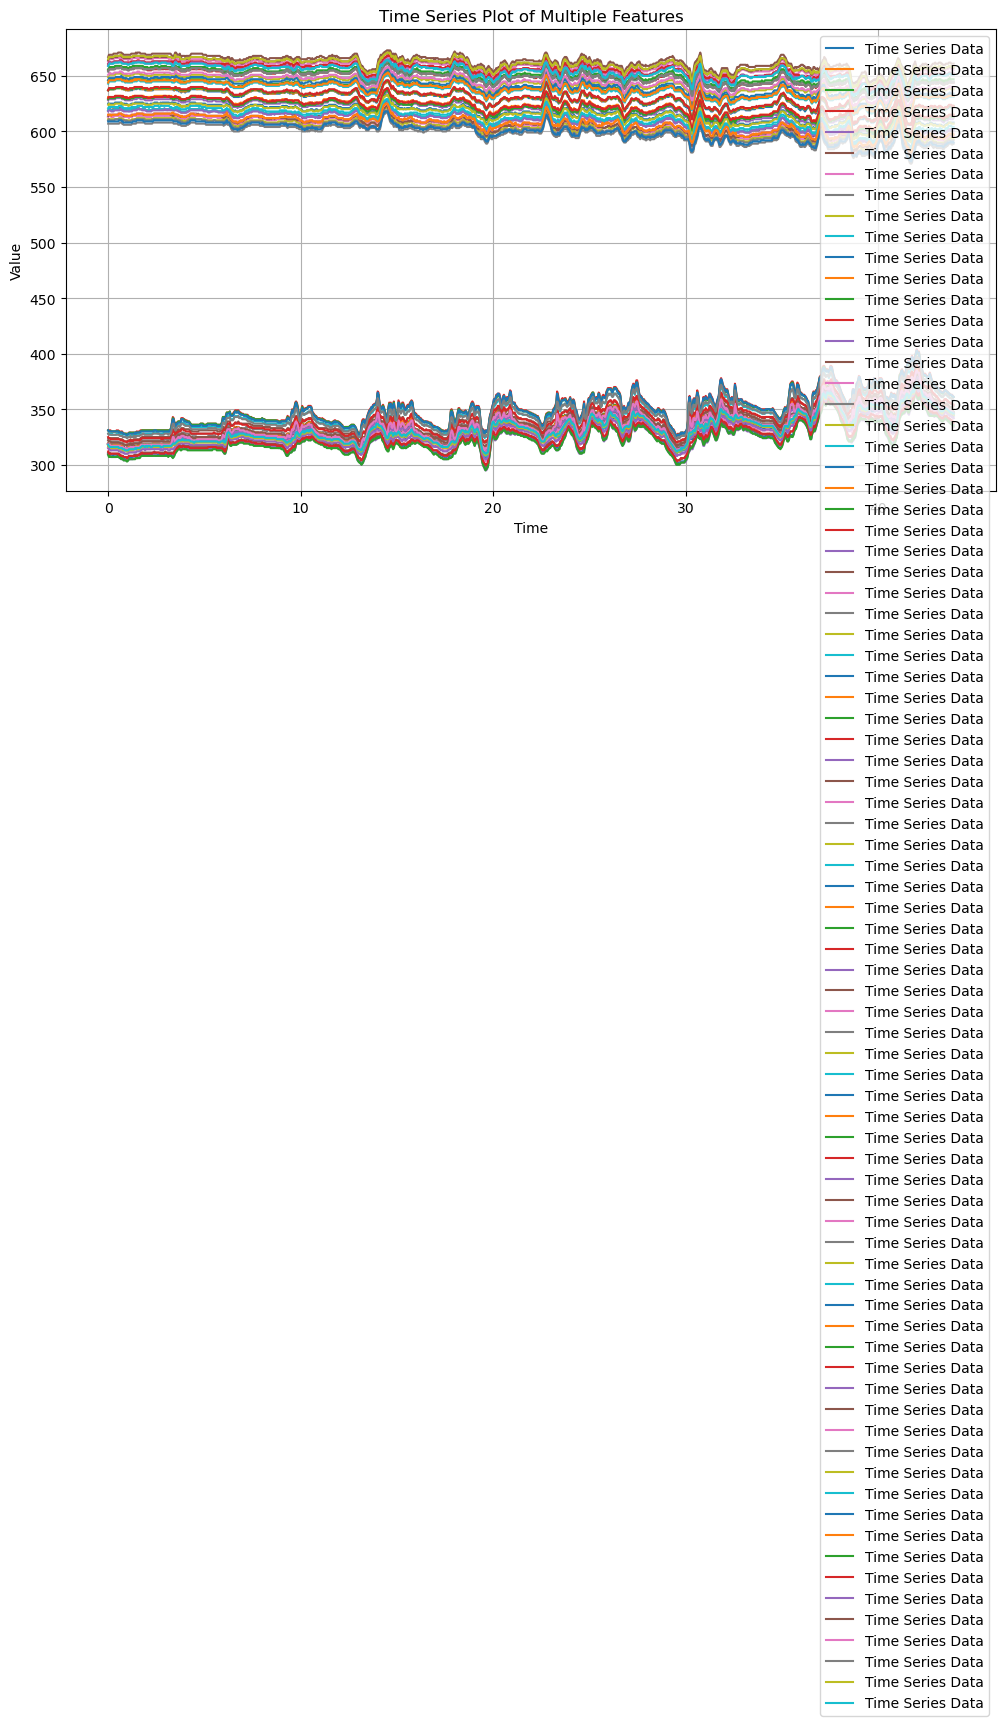

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
file_path = "data/lip_coordinates.csv"
df = pd.read_csv(file_path)
df.set_index("time", inplace=True)

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df.index.is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df, label="Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of Multiple Features")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 4. ADF Durağanlık Testi ve Durağan Olmayanlara Fark Alma
def adf_test(series):
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("Seri durağandır.")
        return True
    else:
        print("Seri durağan değildir.")
        return False

print("Durağanlık Testi Sonuçları:")
non_stationary_columns = []
for column in df.columns:
    print(f"\n{column} için ADF Testi:")
    is_stationary = adf_test(df[column])
    if not is_stationary:
        non_stationary_columns.append(column)

Durağanlık Testi Sonuçları:

0_x için ADF Testi:
ADF Statistic: -2.1645442528685397
p-value: 0.2193645005987338
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağan değildir.

13_x için ADF Testi:
ADF Statistic: -2.2034393172168696
p-value: 0.2049995521218611
Critical Values:
   1%: -3.436419361753321
   5%: -2.864219865461312
   10%: -2.5681968527091907
Seri durağan değildir.

14_x için ADF Testi:
ADF Statistic: -2.1719662865125042
p-value: 0.21657691926162198
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağan değildir.

17_x için ADF Testi:
ADF Statistic: -2.2470378244052447
p-value: 0.18961826581672053
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061954
   10%: -2.5681942108302214
Seri durağan değildir.

37_x için ADF Testi:
ADF Statistic: -2.1981466674290706
p-value: 0.2069187972105
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061

In [11]:
# 5. Sadece Durağan Olmayanlara Fark Alma
df_diff = df.copy()
for column in non_stationary_columns:
    df_diff[column] = df[column].diff()
df_diff = df_diff.dropna()

print(f"Durağan olmayan sütunlar: {non_stationary_columns}")

Durağan olmayan sütunlar: ['0_x', '13_x', '14_x', '17_x', '37_x', '39_x', '40_x', '61_x', '78_x', '80_x', '81_x', '82_x', '84_x', '87_x', '88_x', '91_x', '95_x', '146_x', '178_x', '181_x', '185_x', '191_x', '267_x', '269_x', '310_x', '311_x', '312_x', '314_x', '317_x', '321_x', '375_x', '402_x', '405_x', '95_y', '185_y', '308_y', '321_y', '324_y', '375_y', '415_y']


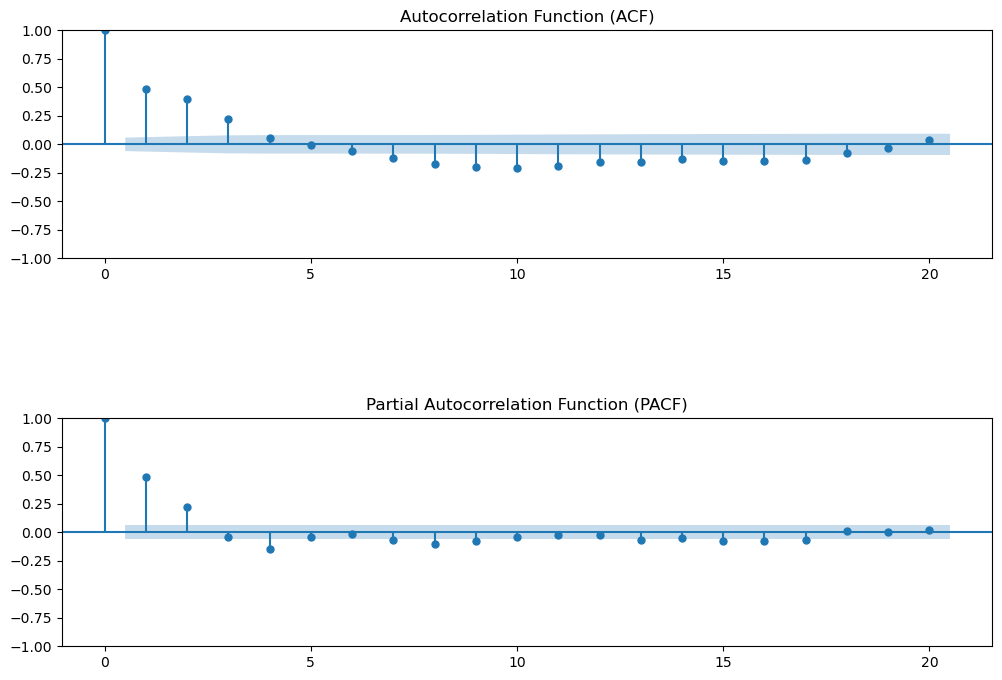

In [12]:
# 6. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_diff.dropna().iloc[:, 0], ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df_diff.dropna().iloc[:, 0], ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [14]:
# 7. VAR Modelini Uygulama
model = VAR(df_diff)
lag_order = model.select_order(maxlags=5)
best_lag = lag_order.aic  # AIC'ye göre en iyi gecikmeyi seçiyoruz
var_model = model.fit(best_lag)
print(var_model.summary())

C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 17, Mar, 2025
Time:                     22:55:43
--------------------------------------------------------------------
No. of Equations:         80.0000    BIC:                   -97.1301
Nobs:                     1096.00    HQIC:                  -133.652
Log likelihood:          -26108.9    FPE:                2.37403e-68
AIC:                     -155.882    Det(Omega_mle):     4.10685e-73
--------------------------------------------------------------------
Results for equation 0_x
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const           19.933161         7.014308            2.842           0.004
L1.0_x          -0.524460         0.071836           -7.301           0.000
L1.13_x          0.106751         0.071823            1.486           0.137
L1.14_

In [15]:
# 8. Tahminlerin Görselleştirilmesi
forecast_steps = 10
forecast = var_model.forecast(df_diff.values[-best_lag:], steps=forecast_steps)

In [16]:
# Tahminleri DataFrame formatına çevirme
forecast_df = pd.DataFrame(forecast, columns=df_diff.columns)

In [17]:
# Orijinal ölçeğe dönüştürme (kümülatif toplam alarak ters farklama)
forecast_df_cumsum = forecast_df.cumsum()
forecast_df_original_scale = forecast_df_cumsum + df.iloc[-1]

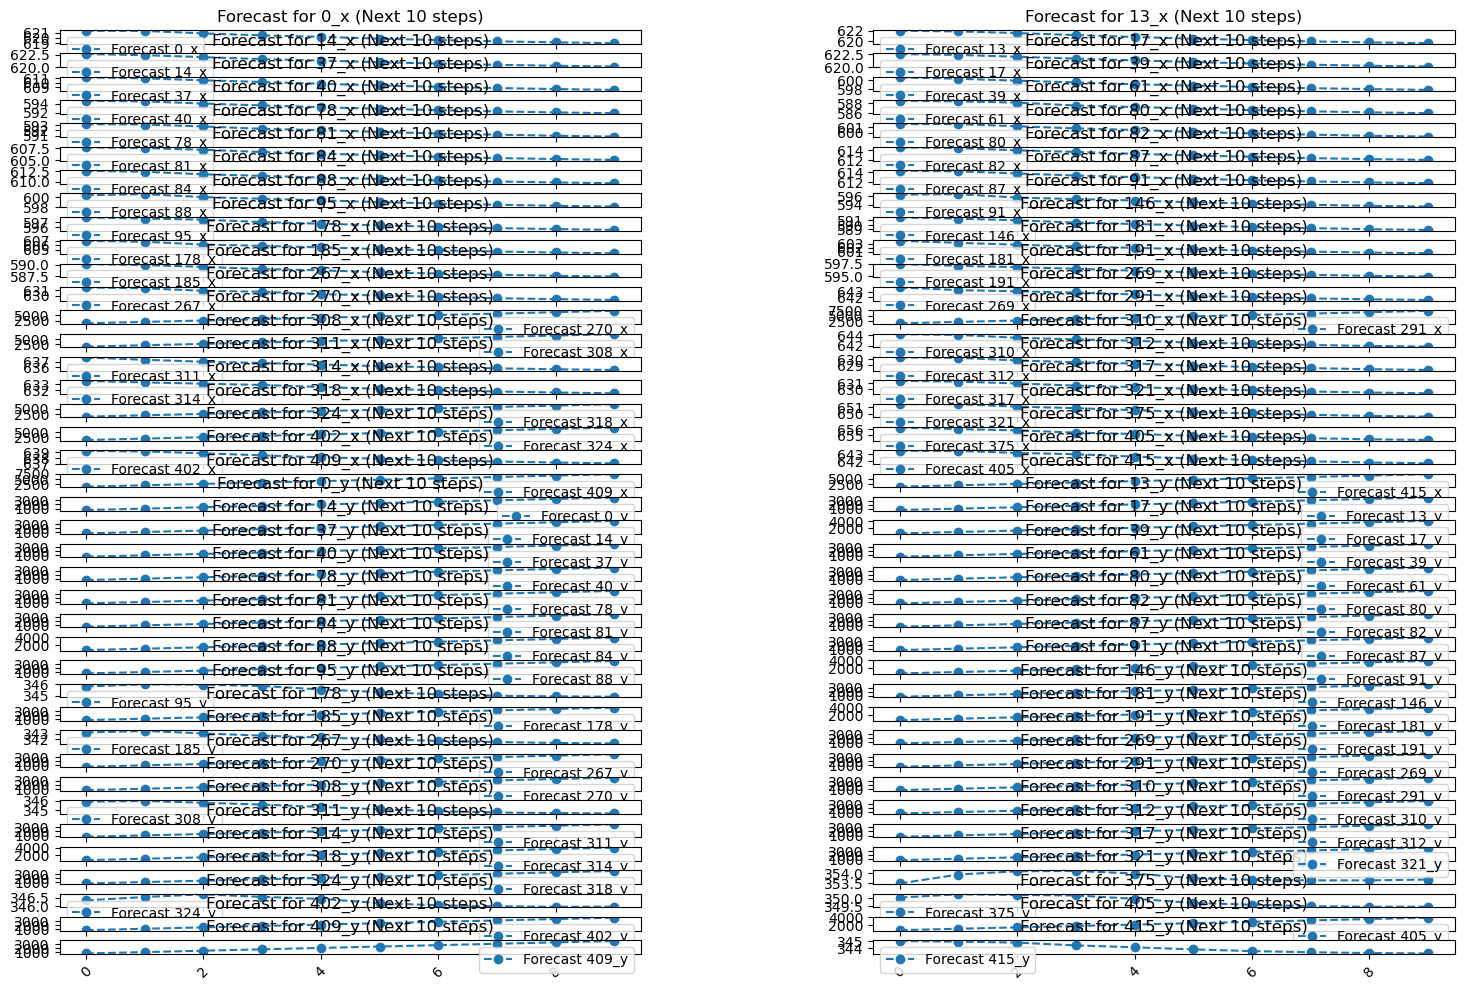

In [18]:
plt.figure(figsize=(18, 12))
num_columns = len(forecast_df.columns)
cols = 2  # 3 yerine 2 sütun kullanarak daha geniş bir görünüm sağla
rows = int(np.ceil(num_columns / cols))  

for i, column in enumerate(forecast_df.columns):
    plt.subplot(rows, cols, i + 1)
    plt.plot(forecast_df_original_scale[column], marker='o', linestyle='dashed', label=f'Forecast {column}')
    plt.title(f'Forecast for {column} (Next {forecast_steps} steps)')
    plt.legend()
    plt.xticks(rotation=45)  # X ekseni etiketlerini döndürerek daha okunaklı hale getir

plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [19]:
# 9. Performans Metriklerini Hesaplama
actual_values = df_diff.iloc[-forecast_steps:].values  # Gerçek fark verileri
predicted_values = forecast_df.values

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / np.where(actual_values != 0, actual_values, np.nan))) * 100

# Her değişken için gerçek ve tahmin edilen değerleri ayrı ayrı yazdıralım
print("Gerçek Değerler vs Tahmin Edilen Değerler:")

for i in range(forecast_steps):
    print(f"\nStep {i+1}:")
    for j, column in enumerate(df_diff.columns):
        print(f"{column} -> Gerçek: {actual_values[i, j]:.4f}, Tahmin: {predicted_values[i, j]:.4f}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:

Step 1:
0_x -> Gerçek: 0.0000, Tahmin: -0.6341
13_x -> Gerçek: 0.0000, Tahmin: -1.0258
14_x -> Gerçek: 1.0000, Tahmin: -0.3755
17_x -> Gerçek: 0.0000, Tahmin: -0.5232
37_x -> Gerçek: 0.0000, Tahmin: -0.9212
39_x -> Gerçek: 0.0000, Tahmin: -0.3204
40_x -> Gerçek: 1.0000, Tahmin: -0.3799
61_x -> Gerçek: 1.0000, Tahmin: -0.4791
78_x -> Gerçek: 1.0000, Tahmin: 0.1978
80_x -> Gerçek: 1.0000, Tahmin: -0.3465
81_x -> Gerçek: 1.0000, Tahmin: -0.3922
82_x -> Gerçek: 1.0000, Tahmin: -0.4436
84_x -> Gerçek: 0.0000, Tahmin: -0.4603
87_x -> Gerçek: 0.0000, Tahmin: -0.6859
88_x -> Gerçek: 1.0000, Tahmin: -0.5947
91_x -> Gerçek: 1.0000, Tahmin: -0.7104
95_x -> Gerçek: 0.0000, Tahmin: -0.1751
146_x -> Gerçek: 1.0000, Tahmin: -0.3584
178_x -> Gerçek: 0.0000, Tahmin: -0.0180
181_x -> Gerçek: 0.0000, Tahmin: -0.2754
185_x -> Gerçek: 1.0000, Tahmin: 0.0832
191_x -> Gerçek: 1.0000, Tahmin: 0.3928
267_x -> Gerçek: 0.0000, Tahmin: -0.4715
269_x -> Gerçek: 0.0000, T